In [1]:
import numpy as np
import networkx as nx
import pprint

from spidercss.cat_at_origin import *
from spidercss.utils import load_qecc
from spidercss.hook_errors import characterize_stabilizer_splits, explain_safe_splits
from spidercss.utils import get_conj_M
from resource_scheduling import plan_resource_aware_reuse
from qubit_reuse import build_circuit_dag
from qubit_reuse import dag_to_circuit


%load_ext autoreload
%autoreload 2

In [2]:
code = "17_1_5"
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)
t = d // 2
basis = "X" if code in ("15_1_3", "49_1_5", "95_1_7") else "Z"
if basis == "X":
    H_x, H_z = H_z, H_x
    L_x, L_z = L_z, L_x
cost, row_M = row_optimize_matrix(H_x, t=t, max_basis_tries=1_000)  # |0>

for r in get_conj_M(row_M):
    print(f"\t[{r[0]}", end="")
    for e in r[1:]:
        print(f", {e}", end="")
    print("],")
print(cost)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


	[0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
	[0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0],
	[1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
	[1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
	[0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
	[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0],
	[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
	[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
	[0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
74


In [3]:
explain_safe_splits(characterize_stabilizer_splits(get_conj_M(row_M)))

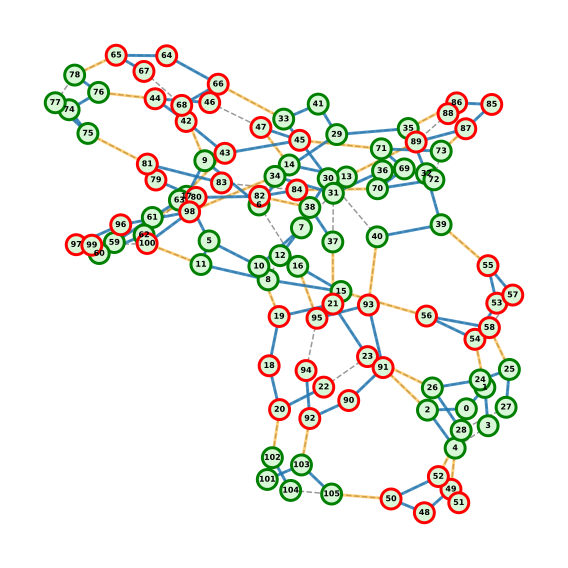

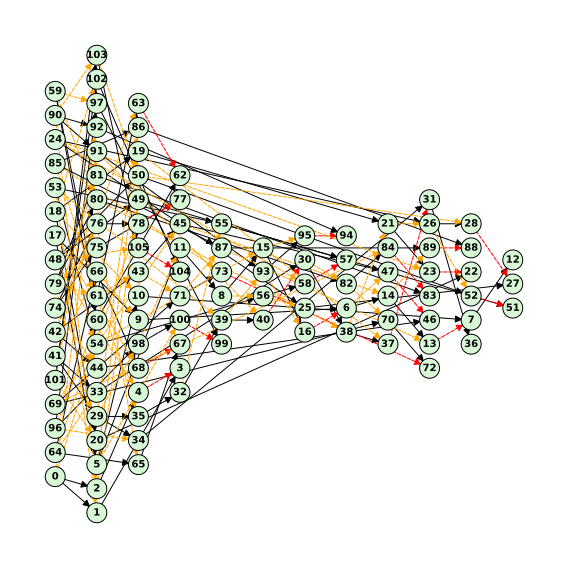

In [4]:
circ = cat_at_origin(row_M, d, basis=basis, draw_solutions=True, analyze_hook_errors=False, is_perfect_code=True)
# circ2 = cat_at_origin(row_M, d, basis=basis, draw_solutions=False, analyze_hook_errors=False)

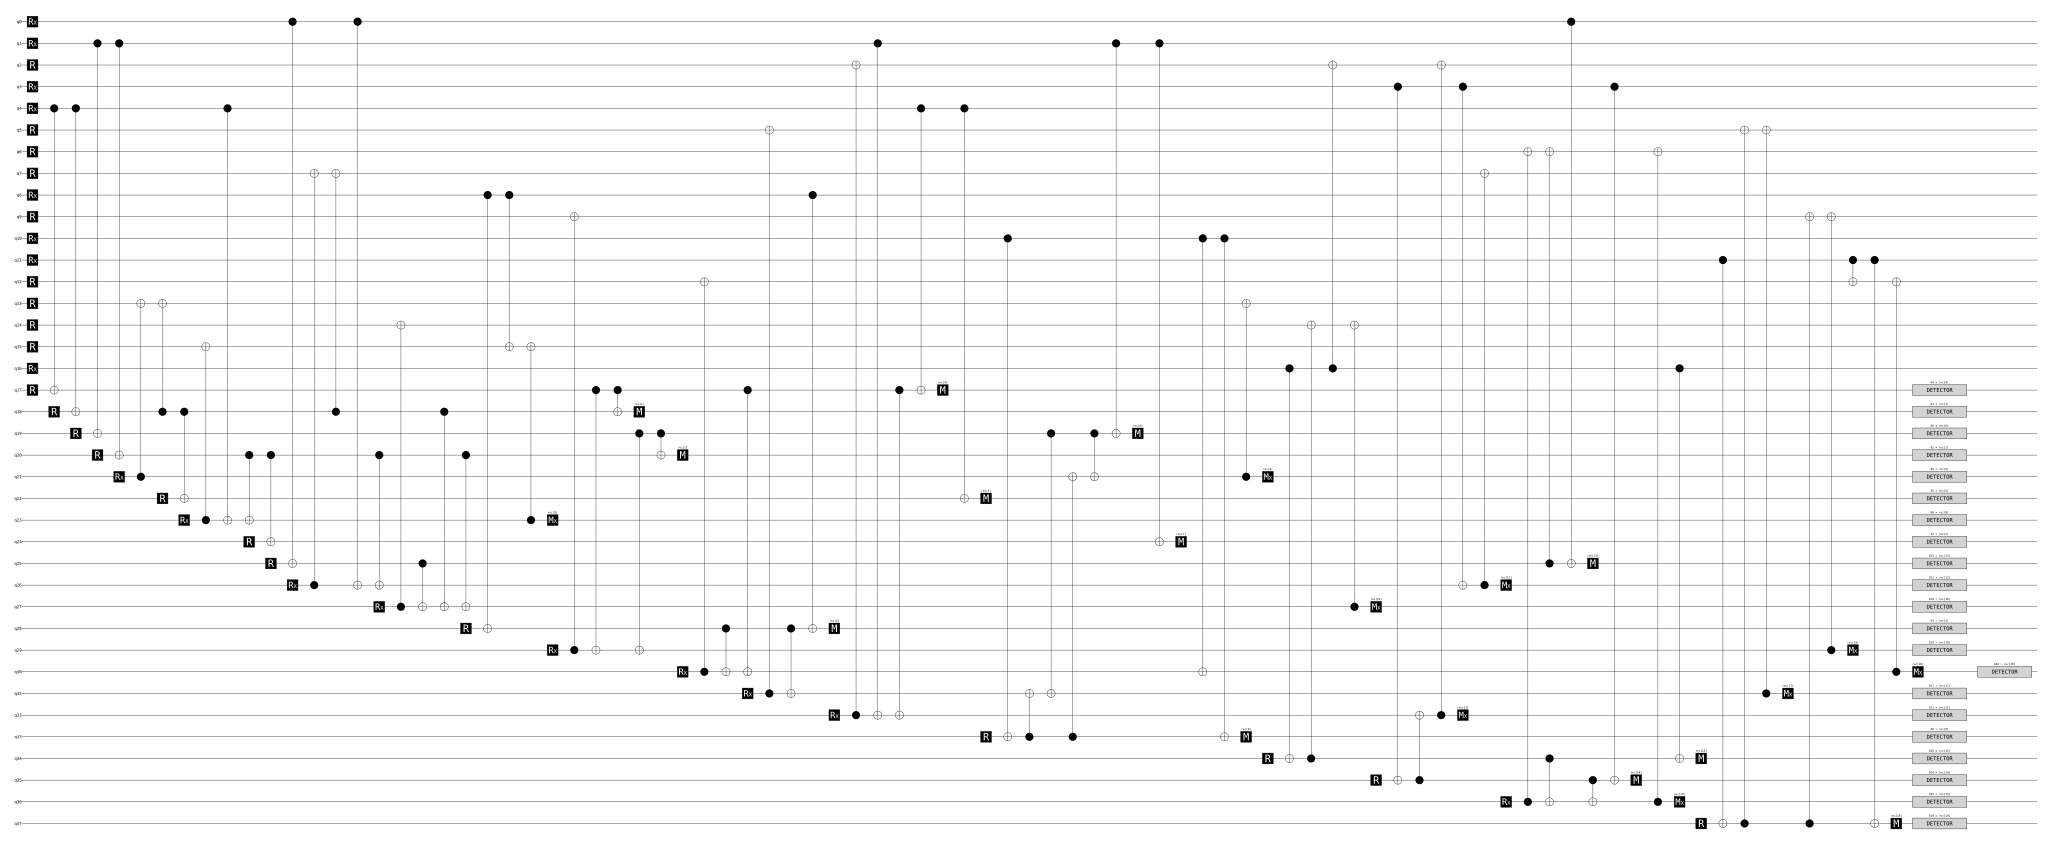

In [5]:
circ.diagram('timeline-svg')

In [6]:
circuit = circ.copy()
circuit.append("M" + basis, range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)
print(meas_samples @ L_z.T % 2)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


In [7]:
from spidercss.utils import _layer_cnot_circuit

raw_cnots = [l for (name, l, _) in circ.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num Flags:", circ.num_qubits - H_z.shape[1])
print("Num qubits:", circ.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))

Num CX: 74
Num Flags: 21
Num qubits: 38
Depth: 12


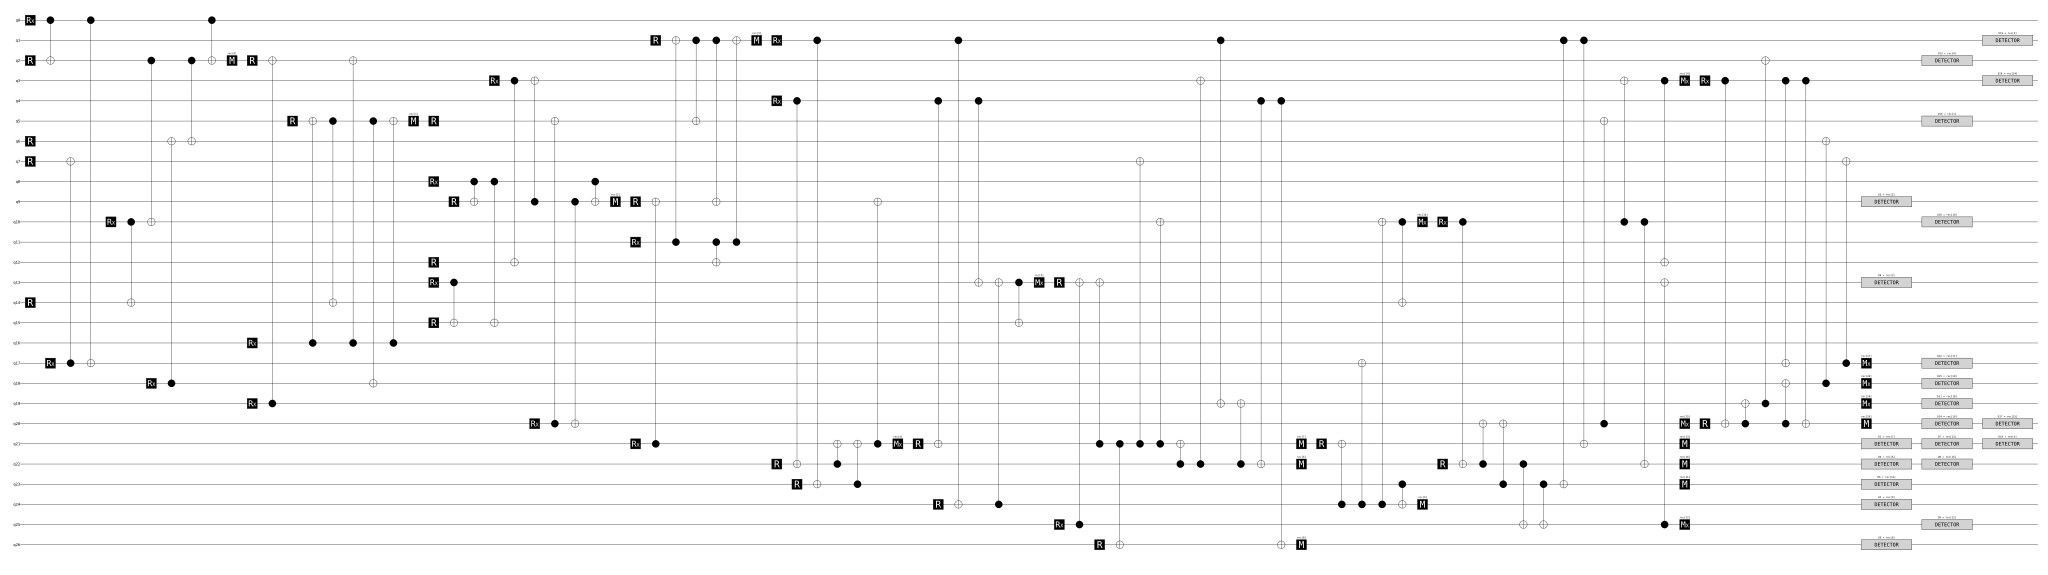

In [8]:
reuse_plan = plan_resource_aware_reuse(
    circ, H_x.shape[1], heuristic="decross_greedy", max_time_seconds=300.0,
    target=ReuseTarget.QUBITS,
)
circ_with_reuse = reuse_plan.circuit
circ_with_reuse.diagram('timeline-svg')

In [9]:
from spidercss.utils import _layer_cnot_circuit

raw_cnots = [l for (name, l, _) in circ_with_reuse.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num qubits:", circ_with_reuse.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))

Num CX: 74
Num qubits: 27
Depth: 38


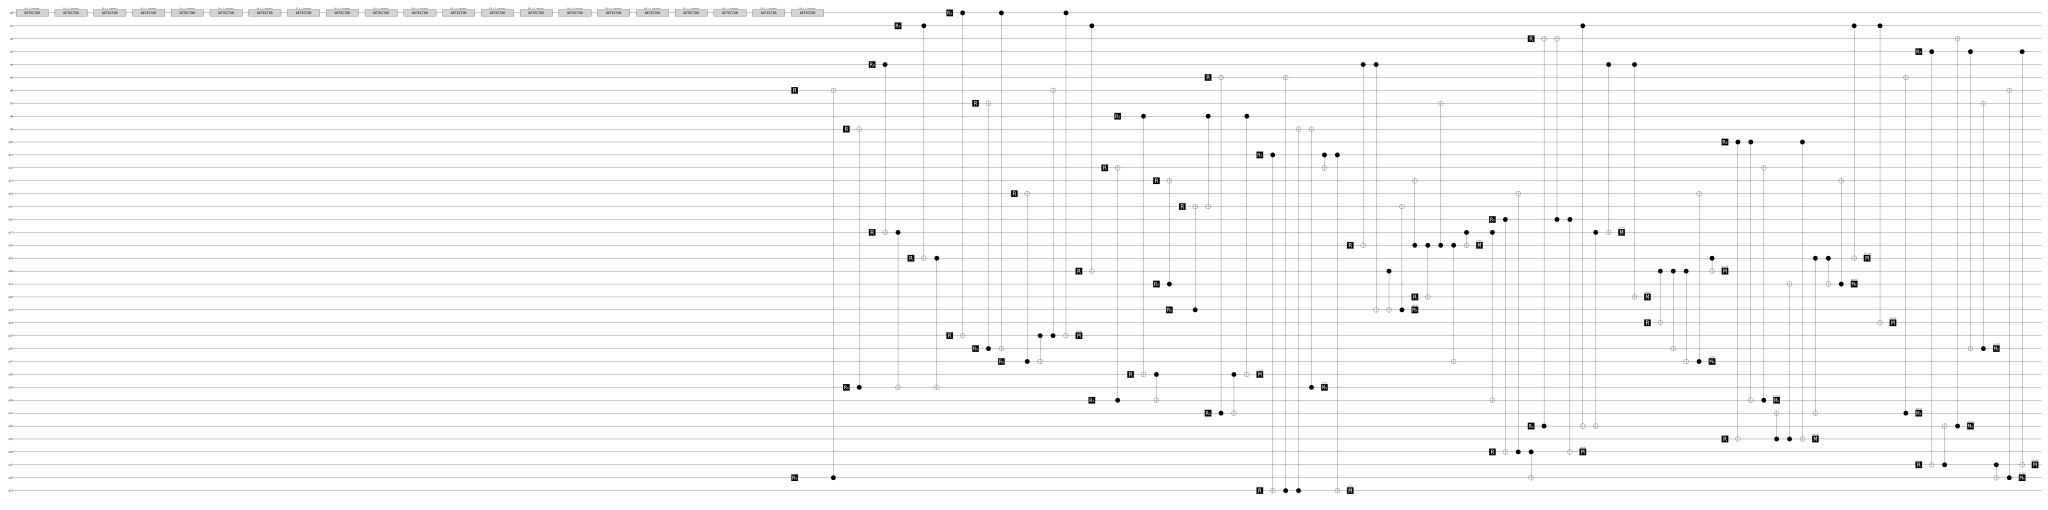

In [11]:
cao_dag = build_circuit_dag(circ)
cao_scheduled, _ = dag_to_circuit(cao_dag, heuristic="exact")
cao_scheduled.diagram('timeline-svg')

Num CX: 74
Num qubits: 23
Depth: 45


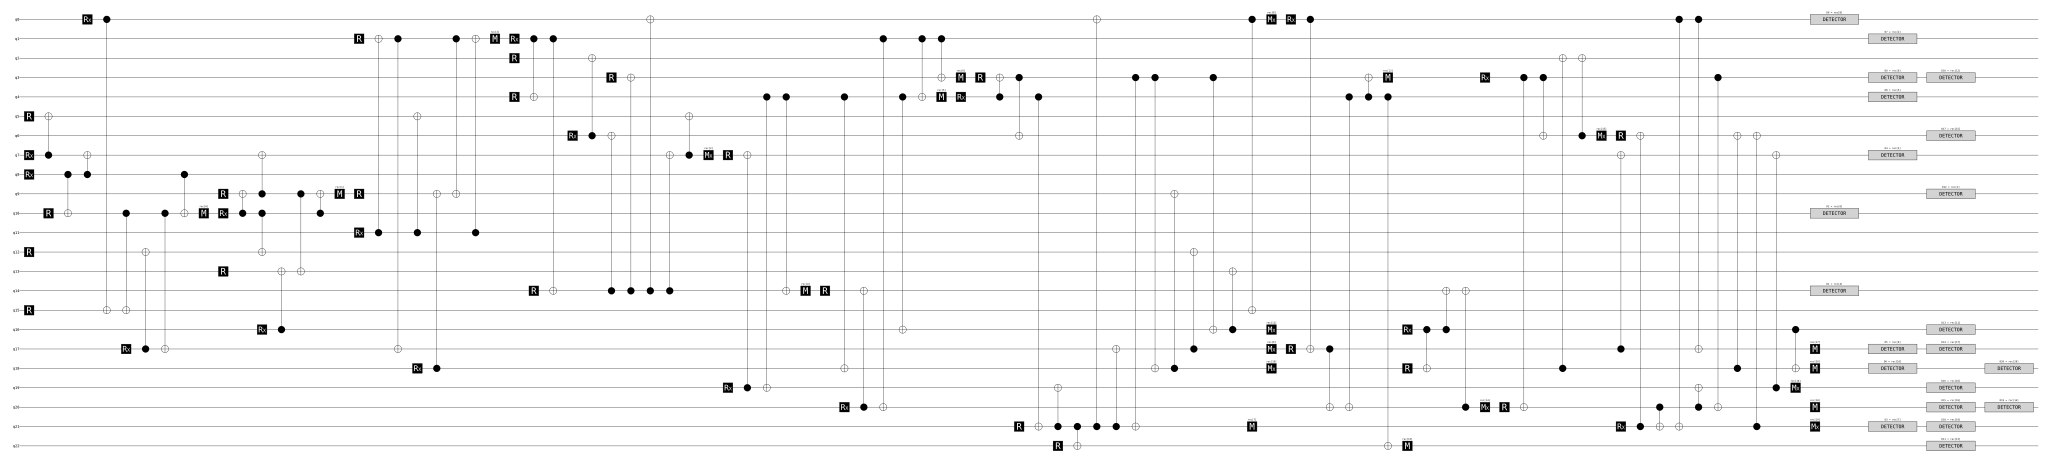

In [13]:
circ_reused = cat_at_origin(row_M, d, basis=basis, draw_solutions=False, analyze_hook_errors=True, reuse_target=ReuseTarget.QUBITS)

raw_cnots = [l for (name, l, _) in circ_reused.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num qubits:", circ_reused.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))

circ_reused.diagram('timeline-svg')